# MEEP Eigenmode Solver — 1D Slab Modes

Solve 1D slab modes with ``sim.mode_solver()`` + ``sim.solve_modes()``.
Runs on GDSFactory+ cloud by default; ``sim.solve_modes_local()`` for local MEEP.

## Part 1 — Quick Start

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np

import gsim.meep as gm
from gsim.common.stack.extractor import Layer, LayerStack
from gsim.common.stack.materials import resolve_material_at_wavelength

RESOLUTION = 128
WL = 1.55
PML = 1.6
n_points = 1000


def _n_si(wl_um: float) -> float:
    """Si refractive index from gsim Sellmeier model (Salzberg & Villa 1957)."""
    return math.sqrt(resolve_material_at_wavelength("si", wl_um).permittivity_scalar)


def _n_sio2(wl_um: float) -> float:
    """SiO2 refractive index from gsim Sellmeier model (Malitson 1965)."""
    return math.sqrt(resolve_material_at_wavelength("sio2", wl_um).permittivity_scalar)


def _make_soi_stack(t_si: float) -> LayerStack:
    """Build a symmetric SOI slab stack: SiO2 / Si / SiO2."""
    t_sio2 = 1.6
    return LayerStack(
        layers={
            "box": Layer(
                name="box",
                gds_layer=(0, 0),
                zmin=-t_sio2,
                zmax=0.0,
                thickness=t_sio2,
                material="sio2",
                layer_type="dielectric",
            ),
            "core": Layer(
                name="core",
                gds_layer=(1, 0),
                zmin=0.0,
                zmax=t_si,
                thickness=t_si,
                material="si",
                layer_type="dielectric",
            ),
            "clad": Layer(
                name="clad",
                gds_layer=(2, 0),
                zmin=t_si,
                zmax=t_si + t_sio2,
                thickness=t_sio2,
                material="sio2",
                layer_type="dielectric",
            ),
        }
    )


soi = _make_soi_stack(0.22)
stack = soi

In [2]:
sim = gm.Simulation()
sim.geometry.stack = stack
sim.solver.resolution = RESOLUTION
sim.domain.pml = PML
sim.mode_solver(wavelengths=[WL], num_bands=1, parity="NO_PARITY")

sweep = sim.solve_modes()
r = sweep.results[0]

print(f"n_eff   = {r.n_eff:.6f}")
print(f"n_group = {r.n_group}")
print(f"kdom    = {[f'{k:.6f}' for k in r.kdom]}")
print(f"band    = {r.band_num}, parity = {r.parity}")

  meep-f484a21c  completed  1m 36s


Extracting results.tar.gz...
Downloaded 2 files to sim-data-meep-f484a21c
n_eff   = 2.841639
n_group = 3.5746946760932166
kdom    = ['1.833315', '-0.000000', '0.000000']
band    = 1, parity = NO_PARITY


## Part 2 — Mode Results

### ModeResult fields

`ModeResult` is a Pydantic model:

| Attribute | Type | Description |
|---|---|---|
| `n_eff` | `float` | Effective index |
| `wavelength` | `float` | Free-space wavelength (um) |
| `fields` | `dict[str, np.ndarray]` | Complex field arrays keyed by component |
| `kdom` | `list[float]` | Dominant wavevector [kx, ky, kz] |
| `n_group` | `float \| None` | Group index (from `mode.group_velocity`) |
| `band_num` | `int` | Mode band index (1 = fundamental) |
| `parity` | `str` | Parity constraint used |

In [3]:
sim.mode_solver(n_field_z=n_points)
sweep = sim.solve_modes()
r = sweep.results[0]

for comp, arr in r.fields.items():
    print(f"{comp}: shape={arr.shape}, |max|={np.abs(arr).max():.6f}")

  meep-ba1d6768  completed  0m 57s


Extracting results.tar.gz...
Downloaded 9 files to sim-data-meep-ba1d6768
Ex: shape=(1000, 1), |max|=0.000228
Ey: shape=(1000, 1), |max|=2.589348
Ez: shape=(1000, 1), |max|=0.000228
Hx: shape=(1000, 1), |max|=3.887137
Hy: shape=(1000, 1), |max|=0.000571
Hz: shape=(1000, 1), |max|=7.358243


### Z-grid and refractive index profile

In [4]:
z_um = gm.mode_z_grid(stack, n_points=n_points, pml_thickness=PML)
n_profile = gm.refractive_index_profile(stack, WL, z_grid=z_um)

print(f"Z grid: {z_um[0]:.4f} ... {z_um[-1]:.4f} um  ({len(z_um)} points)")
print(f"Index range: {n_profile.min():.4f} - {n_profile.max():.4f}")

Z grid: -3.1967 ... 3.4167 um  (1000 points)
Index range: 1.0000 - 3.4777


### Mode profile with index overlay

  meep-12f5eaa7  completed  0m 29s


Extracting results.tar.gz...
Downloaded 9 files to sim-data-meep-12f5eaa7


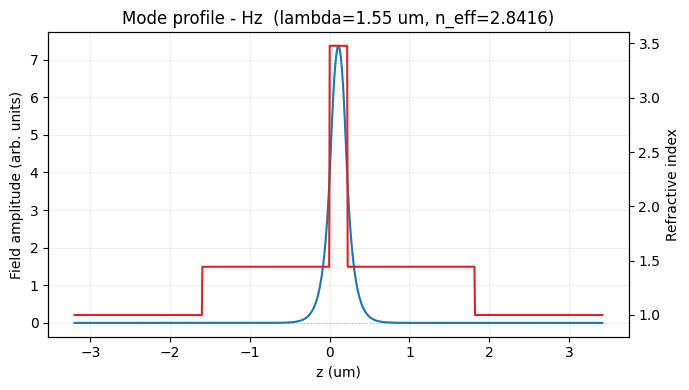

In [5]:
sim.mode_solver(n_field_z=n_points)
sweep = sim.solve_modes()
r = sweep.results[0]

z_slab = gm.mode_z_grid(stack, n_points=n_points, pml_thickness=PML)
n_prof = gm.refractive_index_profile(stack, WL, z_grid=z_slab)
dom_comp = max(r.fields, key=lambda k: np.abs(r.fields[k]).max())

fig, ax = plt.subplots(figsize=(7, 4))
field = r.fields[dom_comp]
ax.plot(z_slab, abs(field), color="C0", linewidth=1.5, label=f"|{dom_comp}|")
ax.plot(
    z_slab,
    field.real,
    color="C0",
    alpha=0.35,
    linestyle="--",
    linewidth=1,
    label=f"Re({dom_comp})",
)
ax.plot(
    z_slab,
    field.imag,
    color="C0",
    alpha=0.35,
    linestyle=":",
    linewidth=1,
    label=f"Im({dom_comp})",
)
ax.set_xlabel("z (um)")
ax.set_ylabel("Field amplitude (arb. units)")

ax_idx = ax.twinx()
ax_idx.plot(z_slab, n_prof, color="C3", linewidth=1.5, label="n(z)")
ax_idx.set_ylabel("Refractive index")
ax_idx.set_ylim(bottom=0.8)

ax.set_title(
    f"Mode profile - {dom_comp}  (lambda={r.wavelength:.2f} um, n_eff={r.n_eff:.4f})"
)
ax.grid(True, alpha=0.2)
fig.tight_layout()

### Field component grid

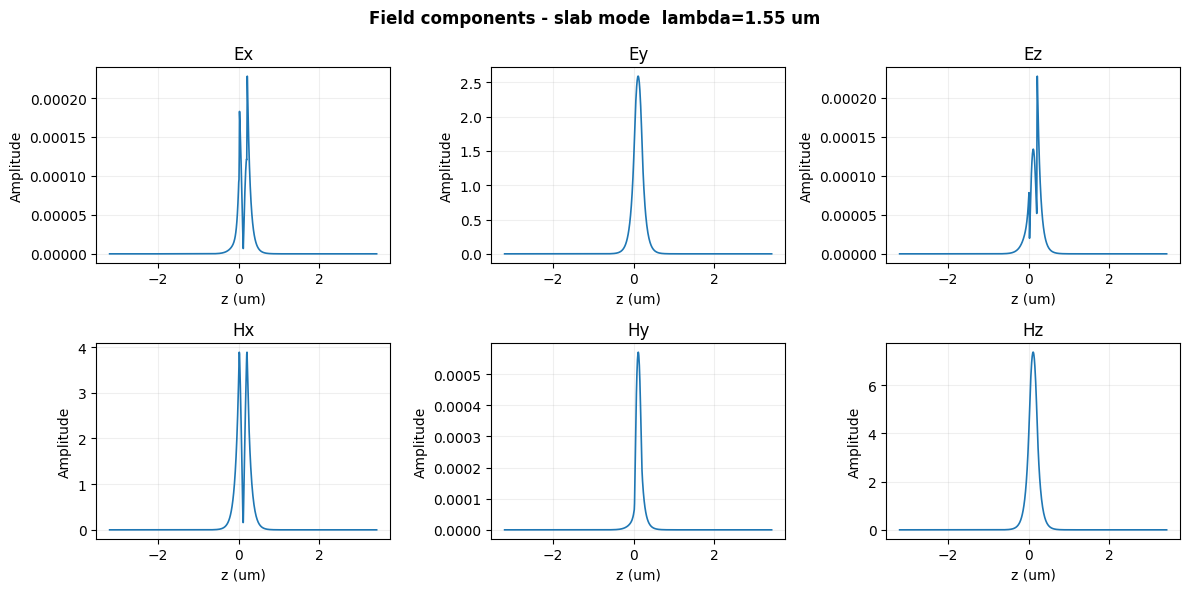

In [6]:
comps = sorted(
    r.fields.keys(),
    key=lambda c: "ExEyEzHxHyHz".index(c) if c in "ExEyEzHxHyHz" else 99,
)
n_cols = min(3, len(comps))
n_rows = (len(comps) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False
)
for idx, comp in enumerate(comps):
    ax = axes[idx // n_cols][idx % n_cols]
    ax.plot(z_slab, np.abs(r.fields[comp]), linewidth=1.2, label=f"|{comp}|")
    ax.set_title(comp)
    ax.set_xlabel("z (um)")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.2)

for idx in range(len(comps), n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

fig.suptitle(
    f"Field components - slab mode  lambda={r.wavelength:.2f} um", fontweight="bold"
)
fig.tight_layout()

## Part 3 — Advanced

### Wavelength sweep & dispersion

`mode_solver.sweep_wavelength(start, stop, num)` populates the wavelength
list linearly.  Multiple wavelengths + single band dispatches to the
efficient shared-cell sweep internally.

In [7]:
sim.mode_solver.sweep_wavelength(1.50, 1.60, 7)
sweep = sim.solve_modes()

# sweep.results are ordered by wavelength ascending
wl_results = {r.wavelength: r for r in sweep.results}
wavelengths = sorted(wl_results)
n_effs = [wl_results[wl].n_eff for wl in wavelengths]
n_groups = [wl_results[wl].n_group for wl in wavelengths]

for wl in wavelengths:
    print(
        f"  lambda = {wl:.2f} um -> n_eff = {wl_results[wl].n_eff:.6f}, n_group = {wl_results[wl].n_group}"
    )

  meep-32c4564c  completed  0m 28s


Extracting results.tar.gz...
Downloaded 45 files to sim-data-meep-32c4564c
  lambda = 1.50 um -> n_eff = 2.869771, n_group = 3.58749318002438
  lambda = 1.52 um -> n_eff = 2.861811, n_group = 3.5849414814474283
  lambda = 1.53 um -> n_eff = 2.853878, n_group = 3.5823067354764304
  lambda = 1.55 um -> n_eff = 2.845975, n_group = 3.5795901604817866
  lambda = 1.57 um -> n_eff = 2.838101, n_group = 3.5767929911614744
  lambda = 1.58 um -> n_eff = 2.830258, n_group = 3.5739164544179163
  lambda = 1.60 um -> n_eff = 2.822445, n_group = 3.570961764734413


### Multi-band modes

The symmetric SOI slab (Si 220 nm core, SiO2 cladding) at lambda=1.55 um
has V-parameter ~ 1.41 -- supports a single TE mode (TE0).
Bands beyond 1 are **leaky / radiation modes**: MEEP's MPB omega-solve
can converge to them because the finite PML-bounded cell discretises
the radiation continuum.  The library logs a warning for modes with
``n_eff`` below the minimum cladding index.

In [8]:
V_param = (2 * np.pi / WL) * 0.22 / 2 * np.sqrt(_n_si(WL) ** 2 - _n_sio2(WL) ** 2)
print(
    f"V-parameter = {V_param:.3f}  ->  {max(1, int(2 * V_param / np.pi) + 1)} guided TE mode(s)"
)

soi_sim = gm.Simulation()
soi_sim.geometry.stack = soi
soi_sim.solver.resolution = RESOLUTION
soi_sim.domain.pml = PML
soi_sim.mode_solver(wavelengths=[WL]).first(4)
band_sweep = soi_sim.solve_modes()

band_results = {r.band_num: r for r in band_sweep.results}
for band, r in sorted(band_results.items()):
    tag = "GUIDED" if r.n_eff > _n_sio2(WL) else "LEAKY"
    print(
        f"  band {band}: n_eff={r.n_eff:.6f}  ({tag})  n_group={r.n_group}  kdom={[f'{k:.4f}' for k in r.kdom[:2]]}..."
    )

  meep-db527558  completed  0m 40s


Extracting results.tar.gz...
Downloaded 2 files to sim-data-meep-db527558
  band 1: n_eff=2.841639  (GUIDED)  n_group=3.5746946760932166  kdom=['1.8333', '-0.0000']...
  band 2: n_eff=2.041738  (GUIDED)  n_group=3.8271473667752773  kdom=['1.3173', '-0.0000']...
  band 3: n_eff=1.431836  (LEAKY)  n_group=1.4642428278391708  kdom=['0.9238', '-0.0000']...
  band 4: n_eff=1.431836  (LEAKY)  n_group=-1.4641486410610316  kdom=['-0.9238', '0.0000']...


### Multi-band field profiles

  meep-b59b3165  completed  0m 34s


Extracting results.tar.gz...
Downloaded 27 files to sim-data-meep-b59b3165


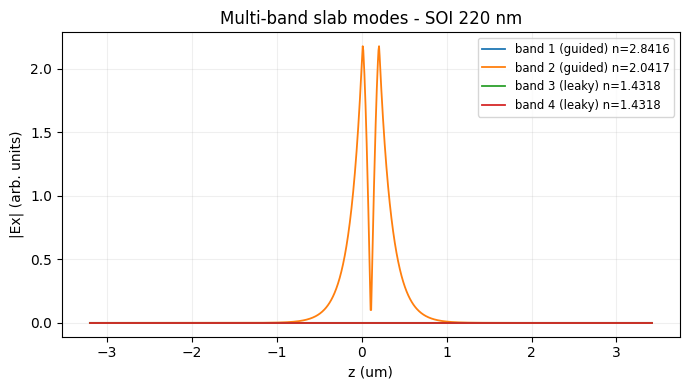

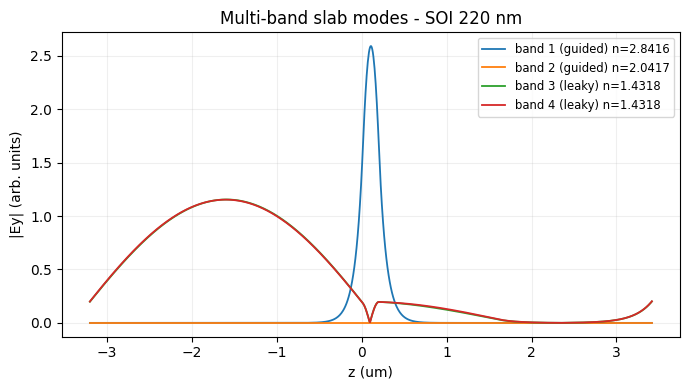

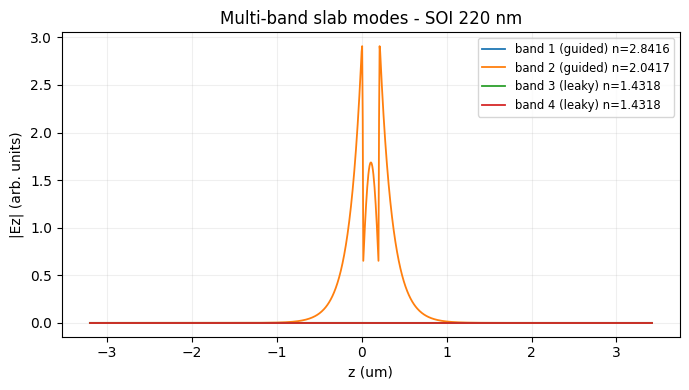

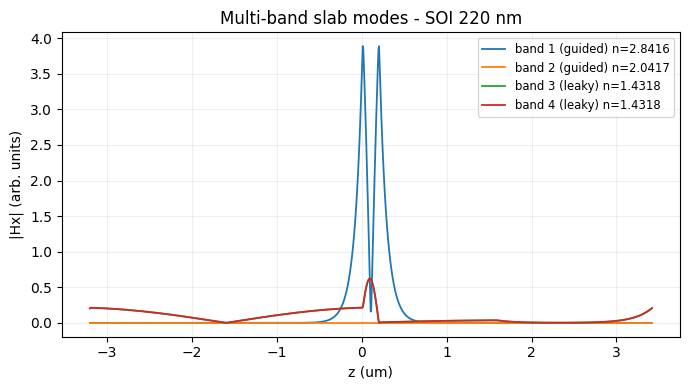

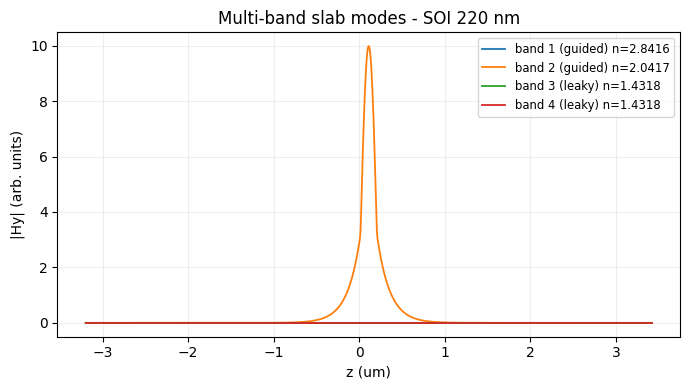

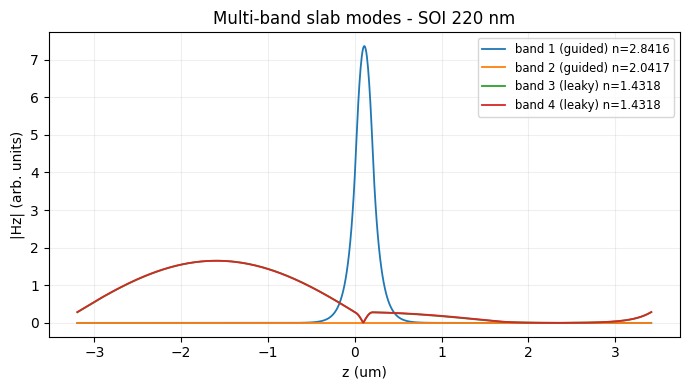

In [9]:
soi_sim.mode_solver(n_field_z=n_points)
band_sweep = soi_sim.solve_modes()
band_results = {r.band_num: r for r in band_sweep.results}

zz = gm.mode_z_grid(soi, n_points=n_points, pml_thickness=PML)

for comp in ("Ex", "Ey", "Ez", "Hx", "Hy", "Hz"):
    fig, ax = plt.subplots(figsize=(7, 4))
    for band, r in sorted(band_results.items()):
        if comp in r.fields:
            tag = "guided" if r.n_eff > _n_sio2(WL) else "leaky"
            ax.plot(
                zz,
                abs(r.fields[comp]),
                linewidth=1.3,
                label=f"band {band} ({tag}) n={r.n_eff:.4f}",
            )
    ax.set_xlabel("z (um)")
    ax.set_ylabel(f"|{comp}| (arb. units)")
    ax.set_title("Multi-band slab modes - SOI 220 nm")
    ax.legend(fontsize="small", loc="upper right")
    ax.grid(True, alpha=0.2)
    fig.tight_layout()

### Parity modes

MEEP's eigenmode solver supports parity constraints along Y and Z.
For the symmetric SOI slab, ``EVEN_Y`` selects TE0.  ``ODD_Y`` selects
the first odd-symmetry mode -- leaky if V < pi/2 ~ 1.57.

In [10]:
parities = ["NO_PARITY", "EVEN_Y", "ODD_Y"]
for parity in parities:
    try:
        p_sim = gm.Simulation()
        p_sim.geometry.stack = soi
        p_sim.solver.resolution = RESOLUTION
        p_sim.domain.pml = PML
        p_sim.mode_solver(wavelengths=[WL], band=1, parity=parity)
        r = p_sim.solve_modes().results[0]
        tag = "guided" if r.n_eff > _n_sio2(WL) else "leaky"
        print(f"  {parity:10s}: n_eff={r.n_eff:.6f}  ({tag})")
    except RuntimeError as exc:
        print(f"  {parity:10s}: not found ({exc})")

  meep-2ff98026  completed  0m 24s


Extracting results.tar.gz...
Downloaded 2 files to sim-data-meep-2ff98026
  ODD_Y     : n_eff=2.041738  (guided)


## Part 4 — Validation

### Analytical SOI slab benchmark

Validate against the analytical transcendental equation for a symmetric
dielectric slab waveguide.

**Structure:** Si core (n=3.4777), thickness 220 nm, SiO2 cladding (n=1.4440).

**Even:**  $\tan(\kappa t/2) = \gamma / \kappa$
**Odd:**   $\tan(\kappa t/2) = -\kappa / \gamma$

where $\kappa = \sqrt{n_\mathrm{core}^2 k_0^2 - \beta^2}$,
$\gamma = \sqrt{\beta^2 - n_\mathrm{clad}^2 k_0^2}$,
$k_0 = 2\pi/\lambda$

In [11]:
def solve_slab_analytical(
    wavelength: float,
    n_core: float,
    n_clad: float,
    t_core: float,
    polarization: str = "TE",
) -> dict[int, float]:
    """Solve the symmetric slab transcendental equation.

    Args:
        wavelength: Free-space wavelength (um).
        n_core: Core refractive index.
        n_clad: Cladding refractive index.
        t_core: Core thickness (um).
        polarization: ``"TE"`` or ``"TM"``.

    Returns:
        Dict mapping mode number (0=fundamental) to n_eff.
    """
    k0 = 2.0 * np.pi / wavelength

    def _te_even(beta: float) -> float:
        kappa = np.sqrt(max(n_core**2 * k0**2 - beta**2, 0))
        gamma = np.sqrt(max(beta**2 - n_clad**2 * k0**2, 0))
        if kappa == 0:
            return -1e6
        return np.tan(kappa * t_core / 2) - gamma / kappa

    def _te_odd(beta: float) -> float:
        kappa = np.sqrt(max(n_core**2 * k0**2 - beta**2, 0))
        gamma = np.sqrt(max(beta**2 - n_clad**2 * k0**2, 0))
        if gamma == 0:
            return -1e6
        return np.tan(kappa * t_core / 2) + kappa / gamma

    if polarization == "TE":
        fns = [_te_even, _te_odd]
    else:

        def _tm_even(beta: float) -> float:
            kappa = np.sqrt(max(n_core**2 * k0**2 - beta**2, 0))
            gamma = np.sqrt(max(beta**2 - n_clad**2 * k0**2, 0))
            if kappa == 0:
                return -1e6
            return np.tan(kappa * t_core / 2) - gamma / kappa * (n_core / n_clad) ** 2

        def _tm_odd(beta: float) -> float:
            kappa = np.sqrt(max(n_core**2 * k0**2 - beta**2, 0))
            gamma = np.sqrt(max(beta**2 - n_clad**2 * k0**2, 0))
            if gamma == 0:
                return -1e6
            return np.tan(kappa * t_core / 2) + kappa / gamma * (n_clad / n_core) ** 2

        fns = [_tm_even, _tm_odd]

    beta_min = n_clad * k0
    beta_max = n_core * k0

    results: dict[int, float] = {}
    mode_idx = 0
    for fn in fns:
        betas = np.linspace(beta_min + 1e-4, beta_max - 1e-4, 10000)
        vals = np.array([fn(b) for b in betas])
        sign_changes = np.where(np.diff(np.signbit(vals)))[0]
        for si in sign_changes:
            b_lo = betas[si]
            b_hi = betas[min(si + 1, len(betas) - 1)]
            try:
                from scipy.optimize import bisect

                beta_root = bisect(fn, b_lo, b_hi, xtol=1e-12)
                n_eff = beta_root / k0

                kappa = np.sqrt(max(n_core**2 * k0**2 - beta_root**2, 0))
                gamma = np.sqrt(max(beta_root**2 - n_clad**2 * k0**2, 0))
                if gamma <= 0 or kappa <= 0:
                    continue
                kt2 = kappa * t_core / 2.0
                if abs(np.tan(kt2)) > 1e4:
                    continue

                if n_eff not in results.values():
                    results[mode_idx] = n_eff
                    mode_idx += 1
            except Exception:
                pass

    return results


def _analytical_ngroup(
    wavelength: float,
    n_core: float,
    n_clad: float,
    t_core: float,
    polarization: str = "TE",
) -> dict[int, float]:
    """Group index from analytic derivative of the characteristic equation.

    Uses implicit differentiation: n_g = dbeta/dk0 = -dF/dk0 / dF/dbeta.
    """
    k0 = 2.0 * np.pi / wavelength
    n1, n2 = n_core, n_clad
    t = t_core

    if polarization == "TE":

        def _even_fn(beta: float) -> float:
            kappa = np.sqrt(max(n1**2 * k0**2 - beta**2, 0))
            gamma = np.sqrt(max(beta**2 - n2**2 * k0**2, 0))
            if kappa == 0:
                return -1e6
            return kappa * np.tan(kappa * t / 2) - gamma

        def _odd_fn(beta: float) -> float:
            kappa = np.sqrt(max(n1**2 * k0**2 - beta**2, 0))
            gamma = np.sqrt(max(beta**2 - n2**2 * k0**2, 0))
            if gamma == 0:
                return -1e6
            return gamma * np.tan(kappa * t / 2) + kappa

        def _te_even_n_g(n_eff: float, kappa: float, gamma: float) -> float:
            k2 = kappa**2
            g2 = gamma**2
            com = gamma / k2 + (t / 2) * (1 + g2 / k2) + 1 / gamma
            num = n1**2 * gamma / k2 + n1**2 * (t / 2) * (1 + g2 / k2) + n2**2 / gamma
            return num / (n_eff * com)

        def _te_odd_n_g(n_eff: float, kappa: float, gamma: float) -> float:
            k2 = kappa**2
            g2 = gamma**2
            com = kappa / g2 + gamma * t / (2 * kappa) * (1 + k2 / g2) + 1 / kappa
            num = (
                n2**2 * kappa / g2
                + n1**2 * gamma * t / (2 * kappa) * (1 + k2 / g2)
                + n1**2 / kappa
            )
            return num / (n_eff * com)

        fns = [(_even_fn, _te_even_n_g), (_odd_fn, _te_odd_n_g)]
    else:
        # TM modes not implemented for analytic group index
        return {}

    beta_min = n2 * k0
    beta_max = n1 * k0

    results: dict[int, float] = {}
    seen_neff: set[float] = set()
    mode_idx = 0
    for fn, ng_fn in fns:
        betas = np.linspace(beta_min + 1e-4, beta_max - 1e-4, 10000)
        vals = np.array([fn(b) for b in betas])
        sign_changes = np.where(np.diff(np.signbit(vals)))[0]
        for si in sign_changes:
            b_lo = betas[si]
            b_hi = betas[min(si + 1, len(betas) - 1)]
            try:
                from scipy.optimize import bisect

                beta_root = bisect(fn, b_lo, b_hi, xtol=1e-12)
                n_eff = beta_root / k0
                kappa = np.sqrt(max(n1**2 * k0**2 - beta_root**2, 0))
                gamma = np.sqrt(max(beta_root**2 - n2**2 * k0**2, 0))
                if gamma <= 0 or kappa <= 0:
                    continue
                kt2 = kappa * t / 2.0
                if abs(np.tan(kt2)) > 1e4:
                    continue
                n_eff_rounded = round(n_eff, 10)
                if n_eff_rounded in seen_neff:
                    continue
                seen_neff.add(n_eff_rounded)
                results[mode_idx] = ng_fn(n_eff, kappa, gamma)
                mode_idx += 1
            except Exception:
                pass

    return results


analytical = solve_slab_analytical(
    wavelength=WL, n_core=_n_si(WL), n_clad=_n_sio2(WL), t_core=0.22, polarization="TE"
)
print("Analytical TE slab modes (Si 220nm / SiO2):")
for mode, n_eff in sorted(analytical.items()):
    print(f"  TE{mode}: n_eff = {n_eff:.6f}")

Analytical TE slab modes (Si 220nm / SiO2):
  TE0: n_eff = 2.849489


### Compare MEEP with analytical

In [12]:
# MEEP fundamental TE0 via Simulation API
meep_sim = gm.Simulation()
meep_sim.geometry.stack = soi
meep_sim.solver.resolution = RESOLUTION
meep_sim.domain.pml = PML
meep_sim.mode_solver(wavelengths=[WL], band=1, parity="EVEN_Y")
r_meep = meep_sim.solve_modes().results[0]

if 0 in analytical:
    n_analytical = analytical[0]
    rel_error = abs(r_meep.n_eff - n_analytical) / n_analytical
    print(f"MEEP  TE0: n_eff = {r_meep.n_eff:.6f}")
    print(f"Anal. TE0: n_eff = {n_analytical:.6f}")
    print(f"Relative error: {rel_error:.2e}")
else:
    print("No analytical TE0 mode found.")

# Higher-order modes
meep_sim.mode_solver(wavelengths=[WL]).first(4).at_slab()
higher = meep_sim.solve_modes()
for r in higher.results:
    if r.band_num > 1:
        print(f"\nMEEP  band {r.band_num}: n_eff = {r.n_eff:.6f}")

  meep-a1d52d22  completed  0m 40s


Extracting results.tar.gz...
Downloaded 2 files to sim-data-meep-a1d52d22

MEEP  band 2: n_eff = 1.477477

MEEP  band 3: n_eff = 1.384003

MEEP  band 4: n_eff = 1.526451


### Wavelength sweep — Meep vs Analytical

  lambda=1.50 um   n_eff: M=2.869771 A=2.877505 err=2.69e-03   n_group: M=3.58749318002438 A=3.5912130444516968 err=1.04e-03
  lambda=1.52 um   n_eff: M=2.861811 A=2.868084 err=2.19e-03   n_group: M=3.5849414814474283 A=3.5870805068783036 err=5.96e-04
  lambda=1.53 um   n_eff: M=2.853878 A=2.858747 err=1.70e-03   n_group: M=3.5823067354764304 A=3.5829169601867954 err=1.70e-04
  lambda=1.55 um   n_eff: M=2.845975 A=2.849489 err=1.23e-03   n_group: M=3.5795901604817866 A=3.578721148111702 err=2.43e-04
  lambda=1.57 um   n_eff: M=2.838101 A=2.840311 err=7.78e-04   n_group: M=3.5767929911614744 A=3.574491992050725 err=6.44e-04
  lambda=1.58 um   n_eff: M=2.830258 A=2.831211 err=3.37e-04   n_group: M=3.5739164544179163 A=3.5702285727919243 err=1.03e-03
  lambda=1.60 um   n_eff: M=2.822445 A=2.822185 err=9.20e-05   n_group: M=3.570961764734413 A=3.5659301148625446 err=1.41e-03


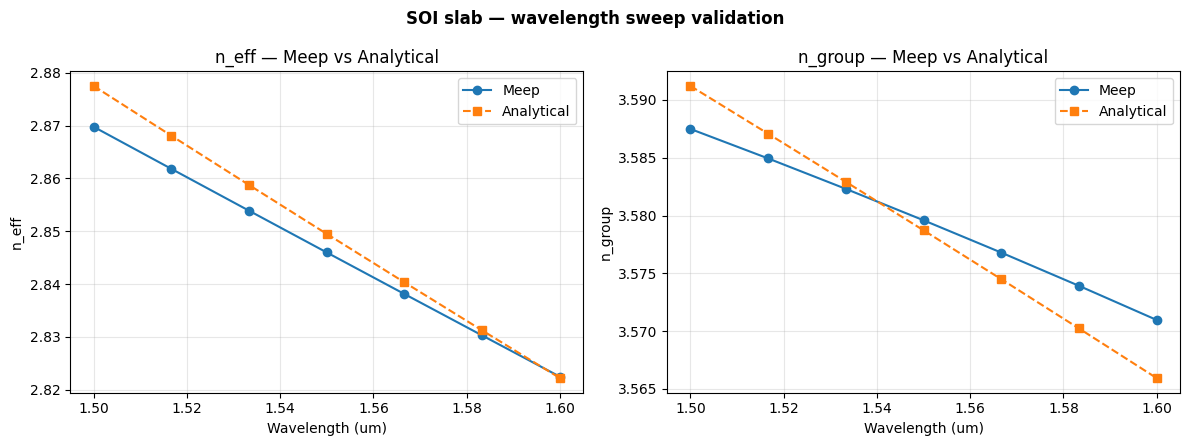

In [13]:
wl_analytical_neff = [
    solve_slab_analytical(wl, _n_si(wl), _n_sio2(wl), 0.22, "TE").get(0)
    for wl in wavelengths
]
wl_analytical_ngroup = [
    _analytical_ngroup(wl, _n_si(wl), _n_sio2(wl), 0.22, "TE").get(0)
    for wl in wavelengths
]

fig, (ax_neff, ax_ng) = plt.subplots(1, 2, figsize=(12, 4.5))

ax_neff.plot(wavelengths, n_effs, "o-", label="Meep", linewidth=1.5)
ax_neff.plot(wavelengths, wl_analytical_neff, "s--", label="Analytical", linewidth=1.5)
ax_neff.set_xlabel("Wavelength (um)")
ax_neff.set_ylabel("n_eff")
ax_neff.set_title("n_eff — Meep vs Analytical")
ax_neff.legend()
ax_neff.grid(True, alpha=0.3)

ax_ng.plot(wavelengths, n_groups, "o-", label="Meep", linewidth=1.5)
ax_ng.plot(wavelengths, wl_analytical_ngroup, "s--", label="Analytical", linewidth=1.5)
ax_ng.set_xlabel("Wavelength (um)")
ax_ng.set_ylabel("n_group")
ax_ng.set_title("n_group — Meep vs Analytical")
ax_ng.legend()
ax_ng.grid(True, alpha=0.3)

fig.suptitle("SOI slab — wavelength sweep validation", fontweight="bold")
fig.tight_layout()

for wl, m_n, m_g, a_n, a_g in zip(
    wavelengths, n_effs, n_groups, wl_analytical_neff, wl_analytical_ngroup
):
    err_n = abs(m_n - a_n) / a_n if a_n else float("nan")
    err_g = abs(m_g - a_g) / a_g if a_g else float("nan")
    print(
        f"  lambda={wl:.2f} um  "
        f" n_eff: M={m_n:.6f} A={a_n:.6f} err={err_n:.2e}  "
        f" n_group: M={m_g} A={a_g} err={err_g:.2e}"
        if a_g
        else f" n_group: M={m_g} A=None"
    )

## Part 5 — Parameter Studies

### Core thickness sweep

Vary the silicon core thickness and re-solve the slab mode. Thicker
cores -> higher confinement -> larger n_eff.

  meep-30626e36  completed  0m 34s


Extracting results.tar.gz...
Downloaded 2 files to sim-data-meep-30626e36
  t_Si = 0.40 um -> n_eff = 3.189095, n_group = 3.60878015295674


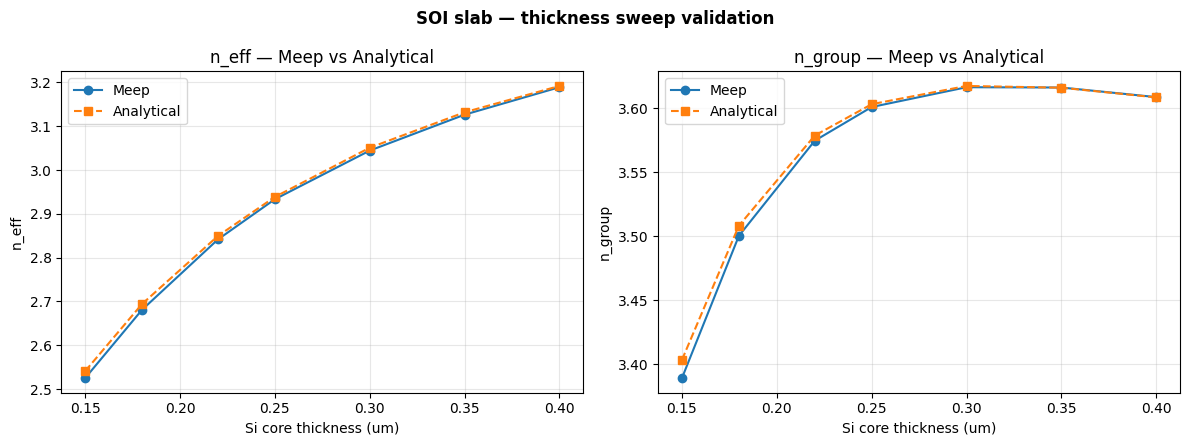

In [14]:
thicknesses = [0.15, 0.18, 0.22, 0.25, 0.30, 0.35, 0.40]

n_eff_thick: list[float] = []
n_group_thick: list[float | None] = []
analytical_thick = [
    solve_slab_analytical(WL, _n_si(WL), _n_sio2(WL), t, "TE").get(0)
    for t in thicknesses
]
analytical_ng_thick = [
    _analytical_ngroup(WL, _n_si(WL), _n_sio2(WL), t, "TE").get(0) for t in thicknesses
]


for t, m_n, a_n, m_g, a_g in zip(
    thicknesses, n_eff_thick, analytical_thick, n_group_thick, analytical_ng_thick
):
    err_n = abs(m_n - a_n) / a_n if a_n else float("nan")
    err_g = abs(m_g - a_g) / a_g if a_g else float("nan")
    print(
        f"  t_Si={t:.2f} um  "
        f" n_eff: M={m_n:.6f} A={a_n:.6f} err={err_n:.2e}  "
        f" n_group: M={m_g} A={a_g:.6f} err={err_g:.2e}"
        if a_g
        else f" n_group: M={m_g} A=None"
    )


for t in thicknesses:
    wg = _make_soi_stack(t)
    ts = gm.Simulation()
    ts.geometry.stack = wg
    ts.solver.resolution = RESOLUTION
    ts.domain.pml = PML
    ts.mode_solver(wavelengths=[WL], band=1, parity="NO_PARITY")
    r = ts.solve_modes().results[0]
    n_eff_thick.append(r.n_eff)
    n_group_thick.append(r.n_group)
    print(f"  t_Si = {t:.2f} um -> n_eff = {r.n_eff:.6f}, n_group = {r.n_group}")


fig, (ax_neff, ax_ng) = plt.subplots(1, 2, figsize=(12, 4.5))

ax_neff.plot(thicknesses, n_eff_thick, "o-", label="Meep", linewidth=1.5)
ax_neff.plot(thicknesses, analytical_thick, "s--", label="Analytical", linewidth=1.5)
ax_neff.set_xlabel("Si core thickness (um)")
ax_neff.set_ylabel("n_eff")
ax_neff.set_title("n_eff — Meep vs Analytical")
ax_neff.legend()
ax_neff.grid(True, alpha=0.3)

ax_ng.plot(thicknesses, n_group_thick, "o-", label="Meep", linewidth=1.5)
ax_ng.plot(thicknesses, analytical_ng_thick, "s--", label="Analytical", linewidth=1.5)
ax_ng.set_xlabel("Si core thickness (um)")
ax_ng.set_ylabel("n_group")
ax_ng.set_title("n_group — Meep vs Analytical")
ax_ng.legend()
ax_ng.grid(True, alpha=0.3)

fig.suptitle("SOI slab — thickness sweep validation", fontweight="bold")
fig.tight_layout()

#